In [1]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

In [3]:
df = pd.read_csv("parking_dataset.csv")
df.head()

,Timestamp,Parking_Lot_ID,Location_Type,Total_Slots,Occupied_Slots,Available_Slots,Occupancy_Rate,Vehicle_Count,Entry_Count,Exit_Count,Vehicle_Type,Traffic_Level,Congestion_Status,Parking_Status,Weather,Temperature,Day_Type,Hour,Revenue,Peak_Hour
0,2026-02-12 12:36:00,PL012,Residential,90,35,55,38.89,50,13,9,EV,Medium,0,0,Cloudy,8.9,Weekday,12,$57.78,0
1,2025-11-22 06:41:00,PL009,Hospital,140,69,71,49.29,78,8,8,Car,Medium,1,0,Cloudy,14.7,Weekend,6,$171.89,0
2,2026-02-13 23:57:00,PL006,Residential,160,90,70,56.25,102,4,10,Car,Medium,1,0,Sunny,11.7,Weekday,23,$153.80,0
3,2026-03-26 20:42:00,PL004,Railway_Station,380,241,139,63.42,308,34,84,Bike,Medium,1,0,Sunny,15.7,Weekday,20,$716.67,1
4,2026-01-19 00:03:00,PL003,Hospital,260,104,156,40.00,119,16,8,Car,Low,0,0,Sunny,8.5,Weekday,0,$229.05,0


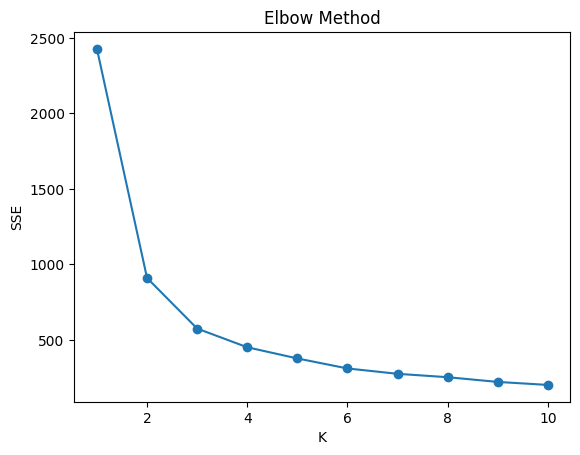

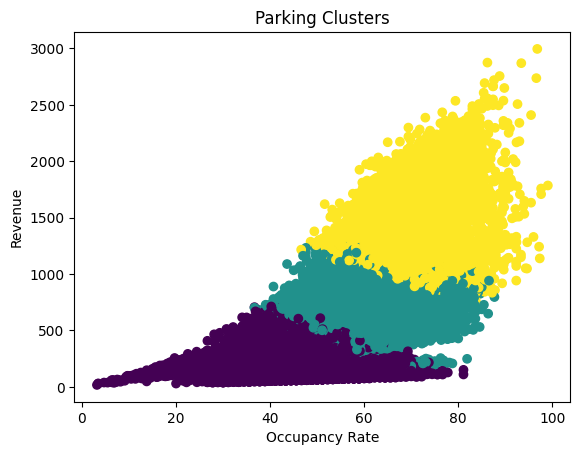

Cluster
0    12366
1    10811
2     6823
Name: count, dtype: int64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Load dataset
df = pd.read_csv('parking_dataset.csv')

# Convert Revenue to float
df['Revenue'] = df['Revenue'].replace(
    '[$,]',
    '',
    regex=True
).astype(float)

# Features
x = df[[
    'Occupancy_Rate',
    'Vehicle_Count',
    'Revenue'
]]

# Scaling
scaler = MinMaxScaler()

x_scaled = scaler.fit_transform(x)

# Elbow Method
sse = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(x_scaled)

    sse.append(model.inertia_)

# Elbow Plot
plt.plot(range(1,11), sse, marker='o')

plt.xlabel('K')
plt.ylabel('SSE')

plt.title('Elbow Method')

plt.show()

# Final Model
model = KMeans(
    n_clusters=3,
    random_state=42
)

df['Cluster'] = model.fit_predict(x_scaled)

# Cluster Visualization
plt.scatter(
    df['Occupancy_Rate'],
    df['Revenue'],
    c=df['Cluster']
)

plt.xlabel('Occupancy Rate')
plt.ylabel('Revenue')

plt.title('Parking Clusters')

plt.show()

# Cluster Counts
print(df['Cluster'].value_counts())